In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

In [4]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['price'] = data.target

In [7]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [8]:
df = df.sample(frac=0.20)

In [9]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
12157,2.3750,11.0,4.942105,0.984211,557.0,2.931579,33.67,-117.07,1.458
9794,10.1854,18.0,6.806452,1.049853,803.0,2.354839,36.53,-121.77,4.260
3536,4.8316,33.0,5.617063,1.011905,1340.0,2.658730,34.26,-118.50,2.373
20055,2.4167,37.0,5.333333,1.202899,564.0,4.086957,35.85,-119.12,0.583
9768,3.0437,20.0,3.860806,0.985348,1219.0,4.465201,36.42,-121.32,0.766
...,...,...,...,...,...,...,...,...,...
13656,1.6675,6.0,5.511509,1.391304,1039.0,2.657289,34.05,-117.30,0.958
2458,3.3214,35.0,5.561798,1.078652,674.0,3.786517,36.52,-119.59,1.016
8198,3.7826,5.0,4.363208,1.170991,1657.0,1.954009,33.79,-118.15,1.963
350,1.4375,48.0,5.017192,1.117479,935.0,2.679083,37.75,-122.17,0.900


In [10]:
x = df.iloc[: ,:-1]
y = df.iloc[: ,-1]

In [11]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
12157,2.3750,11.0,4.942105,0.984211,557.0,2.931579,33.67,-117.07
9794,10.1854,18.0,6.806452,1.049853,803.0,2.354839,36.53,-121.77
3536,4.8316,33.0,5.617063,1.011905,1340.0,2.658730,34.26,-118.50
20055,2.4167,37.0,5.333333,1.202899,564.0,4.086957,35.85,-119.12
9768,3.0437,20.0,3.860806,0.985348,1219.0,4.465201,36.42,-121.32
...,...,...,...,...,...,...,...,...
13656,1.6675,6.0,5.511509,1.391304,1039.0,2.657289,34.05,-117.30
2458,3.3214,35.0,5.561798,1.078652,674.0,3.786517,36.52,-119.59
8198,3.7826,5.0,4.363208,1.170991,1657.0,1.954009,33.79,-118.15
350,1.4375,48.0,5.017192,1.117479,935.0,2.679083,37.75,-122.17


In [12]:
y

12157    1.458
9794     4.260
3536     2.373
20055    0.583
9768     0.766
         ...  
13656    0.958
2458     1.016
8198     1.963
350      0.900
441      1.448
Name: price, Length: 4128, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=1)

In [14]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
y_pred = model.predict(x_test)

In [18]:
y_pred

array([1.555, 1.625, 1.286, ..., 4.699, 0.613, 3.4  ], shape=(1239,))

In [19]:
from sklearn.metrics import r2_score
r2_score(y_pred, y_test)

0.4888376217958219

In [20]:
#hyperparameter  tuning

params = {
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'splitter': ['best', 'random'],
    'max_depth': [1,2,3,4,5,6,10],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [21]:
regressor = DecisionTreeRegressor()

In [24]:
from sklearn.model_selection import GridSearchCV
model = GridSearchCV(regressor, param_grid=params, cv=5, scoring='neg_mean_squared_error', verbose=3)


In [25]:
model.fit(x_train,y_train)

Fitting 5 folds for each of 126 candidates, totalling 630 fits
[CV 1/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 2/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 4/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 5/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 1/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 2/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 4/5] EN

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [26]:
model.best_params_

{'criterion': 'absolute_error',
 'max_depth': 10,
 'max_features': 'log2',
 'splitter': 'best'}

In [27]:
final_model = DecisionTreeRegressor(criterion='absolute_error', max_depth=10, max_features='log2', splitter='best')

In [28]:
final_model.fit(x_train,y_train)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.6496078550583657, 0.9545454545454546, 'x[0] <= 5.285\nabsolute_error = 0.882\nsamples = 2889\nvalue = 1.784'),
 Text(0.4320890077821012, 0.8636363636363636, 'x[1] <= 50.5\nabsolute_error = 0.691\nsamples = 2386\nvalue = 1.625'),
 Text(0.5408484314202334, 0.9090909090909092, 'True  '),
 Text(0.30125243190661477, 0.7727272727272727, 'x[6] <= 38.735\nabsolute_error = 0.649\nsamples = 2202\nvalue = 1.6'),
 Text(0.20099708171206226, 0.6818181818181818, 'x[7] <= -117.515\nabsolute_error = 0.646\nsamples = 2041\nvalue = 1.648'),
 Text(0.10493677042801557, 0.5909090909090909, 'x[0] <= 3.314\nabsolute_error = 0.663\nsamples = 1668\nvalue = 1.742'),
 Text(0.04888132295719844, 0.5, 'x[0] <= 2.156\nabsolute_error = 0.568\nsamples = 840\nvalue = 1.424'),
 Text(0.020428015564202335, 0.4090909090909091, 'x[2] <= 3.495\nabsolute_error = 0.54\nsamples = 282\nvalue = 1.108'),
 Text(0.007782101167315175, 0.3181818181818182, 'x[6] <= 34.075\nabsolute_error = 0.5\nsamples = 67\nvalue = 1.667'),
 Te

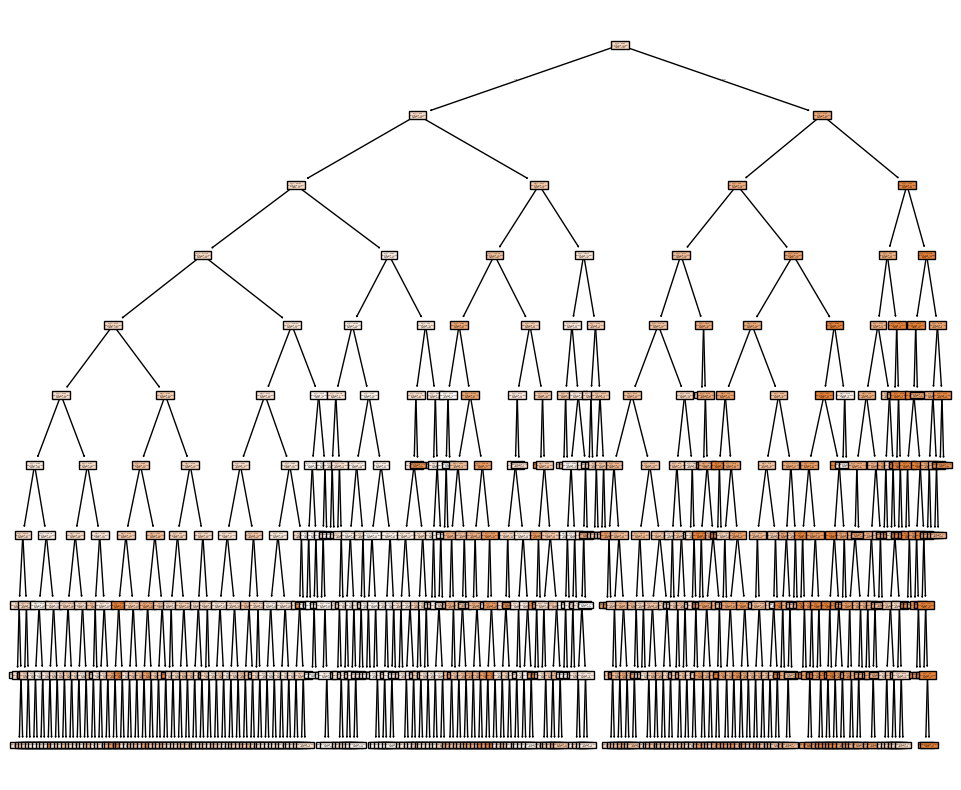

In [29]:
from sklearn import tree
plt.figure(figsize=(12, 10))
tree.plot_tree(final_model, filled=True)

In [31]:
y_pred = final_model.predict(x_test)

In [32]:
r2_score(y_test,y_pred)

0.49601339040213077